#📌 Preprocesamiento y Análisis

--- 1. CARGA Y LIMPIEZA INICIAL ---
Columna 'customerID' eliminada.
Dimensiones después del encoding: (7043, 31)

--- 2. ANÁLISIS DE CHURN ---
Clientes Activos (0): 5174 (73.5%)
Clientes Cancelados (1): 1869 (26.5%)
-> Existe un desbalance de clases evidente (73% vs 27%).


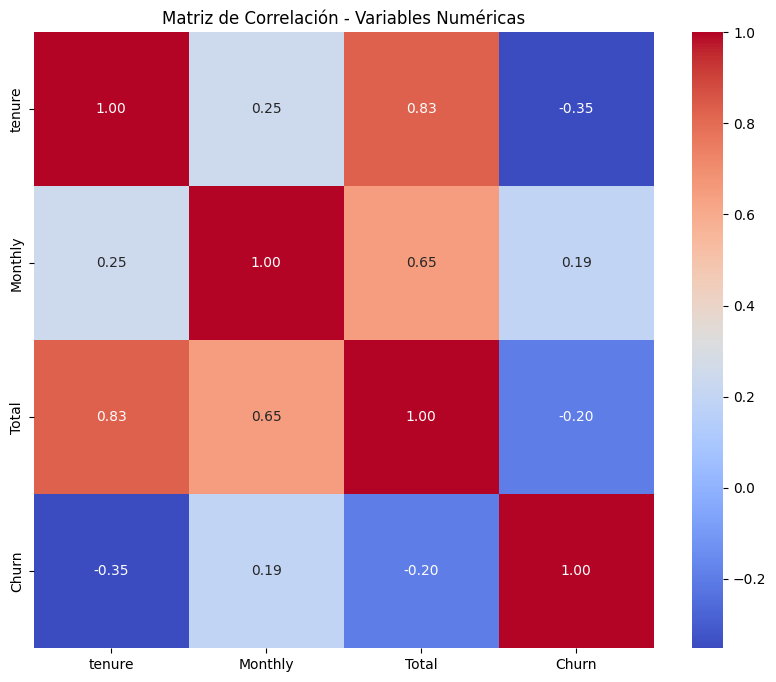

/tmp/ipykernel_491/1154098983.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')


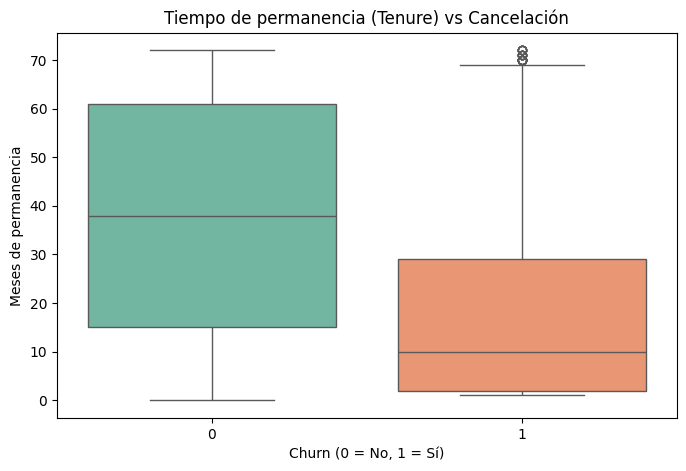

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("--- 1. CARGA Y LIMPIEZA INICIAL ---")
# 1. Carga el archivo tratado
df = pd.read_csv('datos_tratados.csv')

# Eliminamos valores nulos en la variable objetivo (Churn) por precaución
df = df.dropna(subset=['Churn'])

# 2. Eliminación de Columnas Irrelevantes (ID del cliente)
if 'customerID' in df.columns:
    df = df.drop(columns=['customerID'])
    print("Columna 'customerID' eliminada.")

# 3. Encoding (Transformación a numérico)
# Primero convertimos nuestra variable objetivo 'Churn' a 0 y 1 para facilitar el modelado
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Extraemos las variables categóricas restantes para aplicar One-Hot Encoding
cat_cols = df.select_dtypes(include=['object']).columns
# get_dummies es perfecto para esto. drop_first=True evita la multicolinealidad
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)
print(f"Dimensiones después del encoding: {df_encoded.shape}")

# 4. Verificación de la Proporción de Cancelación
churn_counts = df['Churn'].value_counts()
churn_prop = df['Churn'].value_counts(normalize=True) * 100

print("\n--- 2. ANÁLISIS DE CHURN ---")
print(f"Clientes Activos (0): {churn_counts[0]} ({churn_prop[0]:.1f}%)")
print(f"Clientes Cancelados (1): {churn_counts[1]} ({churn_prop[1]:.1f}%)")
print("-> Existe un desbalance de clases evidente (73% vs 27%).")

# 5. Análisis de Correlación
plt.figure(figsize=(10, 8))
# Tomamos solo las variables numéricas originales y la variable Churn para no saturar el gráfico
cols_correlacion = ['tenure', 'Monthly', 'Total', 'Churn']
# Si 'Total' está como string (object), lo convertimos
for col in cols_correlacion:
    if df[col].dtype == 'object':
         df[col] = pd.to_numeric(df[col], errors='coerce')

sns.heatmap(df[cols_correlacion].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlación - Variables Numéricas")
plt.show()

# Análisis Dirigido (Tiempo de contrato vs Cancelación)
plt.figure(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', data=df, palette='Set2')
plt.title('Tiempo de permanencia (Tenure) vs Cancelación')
plt.xlabel('Churn (0 = No, 1 = Sí)')
plt.ylabel('Meses de permanencia')
plt.show()

#🔧 Modelado Predictivo y Evaluación


--- 3. SEPARACIÓN Y BALANCEO DE DATOS ---
Datos balanceados (Train): Activos=3622, Cancelados=3622

--- 4. MODELADO Y NORMALIZACIÓN ---
Entrenando Regresión Logística (con normalización)...
Entrenando Random Forest (sin normalización)...

[ Resultados Regresión Logística ]
Exactitud (Accuracy): 0.7430
Precisión: 0.5103
Recall: 0.7932
F1-Score: 0.6211


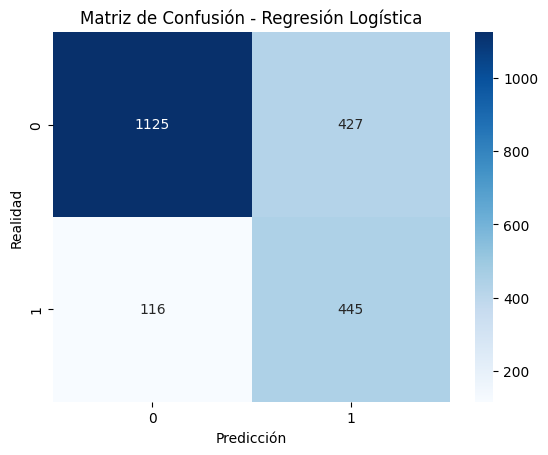


[ Resultados Random Forest ]
Exactitud (Accuracy): 0.7790
Precisión: 0.5897
Recall: 0.5508
F1-Score: 0.5696


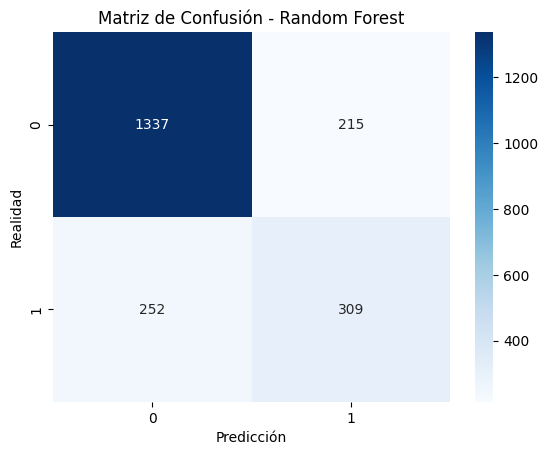

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.utils import resample

print("\n--- 3. SEPARACIÓN Y BALANCEO DE DATOS ---")
# Separación de datos en X e y
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

# División 70/30 (entrenamiento y prueba) stratify asegura que la proporción de churn se mantenga
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Balanceo de Clases en el set de Entrenamiento (Oversampling de la clase minoritaria)
train_data = pd.concat([X_train, y_train], axis=1)
clase_0 = train_data[train_data.Churn == 0]
clase_1 = train_data[train_data.Churn == 1]

# Igualamos la cantidad de cancelaciones a la cantidad de activos
clase_1_oversampled = resample(clase_1, replace=True, n_samples=len(clase_0), random_state=42)
train_data_bal = pd.concat([clase_0, clase_1_oversampled])

X_train_bal = train_data_bal.drop('Churn', axis=1)
y_train_bal = train_data_bal['Churn']
print(f"Datos balanceados (Train): Activos={len(clase_0)}, Cancelados={len(clase_1_oversampled)}")

print("\n--- 4. MODELADO Y NORMALIZACIÓN ---")
# Estandarización (Solo necesaria para Regresión Logística)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test) # OJO: Se transforma el test con el scaler del train

# MODELO 1: REGRESIÓN LOGÍSTICA
print("Entrenando Regresión Logística (con normalización)...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_bal)
y_pred_log = log_reg.predict(X_test_scaled)

# MODELO 2: RANDOM FOREST
print("Entrenando Random Forest (sin normalización)...")
rf = RandomForestClassifier(random_state=42, n_estimators=100)
# Los árboles no son sensibles a la escala, usamos los datos balanceados sin escalar
rf.fit(X_train_bal, y_train_bal)
y_pred_rf = rf.predict(X_test)

def evaluar_modelo(nombre, y_true, y_pred):
    print(f"\n[ Resultados {nombre} ]")
    print(f"Exactitud (Accuracy): {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisión: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_true, y_pred):.4f}")

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.show()

evaluar_modelo("Regresión Logística", y_test, y_pred_log)
evaluar_modelo("Random Forest", y_test, y_pred_rf)

#📊 Importancia de las Variables e Informe

In [4]:
# Análisis de la Importancia de Variables en Regresión Logística
importances = pd.DataFrame({'Variable': X.columns, 'Impacto': log_reg.coef_[0]})
importances = importances.sort_values(by='Impacto', ascending=False)

print("\n--- 5. VARIABLES QUE MÁS INFLUYEN EN LA CANCELACIÓN ---")
print("\nFactores que AUMENTAN la probabilidad de cancelar:")
print(importances.head(5))

print("\nFactores que REDUCEN la probabilidad de cancelar (Fidelización):")
print(importances.tail(5))


--- 5. VARIABLES QUE MÁS INFLUYEN EN LA CANCELACIÓN ---

Factores que AUMENTAN la probabilidad de cancelar:
                          Variable   Impacto
3                            Total  0.710230
10     InternetService_Fiber optic  0.612250
9                MultipleLines_Yes  0.253217
28  PaymentMethod_Electronic check  0.225492
26            PaperlessBilling_Yes  0.204899

Factores que REDUCEN la probabilidad de cancelar (Fidelización):
             Variable   Impacto
19    TechSupport_Yes -0.176571
24  Contract_One year -0.293706
25  Contract_Two year -0.525233
2             Monthly -0.555444
1              tenure -1.460090


#📄Informe final

🔹 **Introducción**

El presente informe detalla el análisis predictivo realizado sobre la base de clientes de Telecom X con el objetivo de anticipar y reducir la tasa de evasión (Churn). La fuga de clientes representa un impacto financiero directo; por ello, la implementación de modelos de Machine Learning permite identificar proactivamente qué usuarios están en riesgo y descubrir los factores subyacentes que motivan su salida, facilitando la toma de decisiones estratégicas.

🔹 **Preparación y Balanceo de Datos**

Durante la fase de limpieza y adecuación (ETL), el identificador único (customerID) fue removido por carecer de valor predictivo. Las variables categóricas fueron transformadas numéricamente mediante One-Hot Encoding, resultando en un conjunto de datos robusto de 7043 registros y 31 variables.

El análisis inicial reveló un desbalance de clases significativo:
- Clientes Activos: 73.5% (5174)

- Clientes Cancelados: 26.5% (1869)

Para evitar que los modelos se sesgaran hacia la clase mayoritaria (prediciendo que nadie cancela), se aplicó una técnica de sobremuestreo (Oversampling). Esto igualó el conjunto de entrenamiento a 3622 casos por clase, garantizando que los algoritmos aprendieran correctamente los patrones de abandono.

🔹 **Evaluación de Modelos Predictivos**

Se entrenaron y compararon dos modelos analíticos. La Regresión Logística requirió la normalización previa de los datos al ser sensible a las escalas numéricas, mientras que el Random Forest se ejecutó sin normalización debido a su arquitectura basada en árboles.

**Resultados del Rendimiento:**
1. Regresión Logística:

  - ***Exactitud (Accuracy): 74.30%***
  - Precisión: 51.03%
- ***Recall: 79.32%***
- F1-Score: 62.11%

2. Random Forest:

- ***Exactitud (Accuracy): 77.90%***

- Precisión: 58.97%

- ***Recall: 55.08%***

- F1-Score: 56.96%


**Análisis Crítico y Selección del Modelo:**

El modelo ganador para este problema de negocio es la Regresión Logística. Aunque el Random Forest presenta una exactitud general ligeramente superior, sufre de un claro underfitting (subajuste) respecto a la clase minoritaria, logrando un Recall de apenas 55%. Esto significa que el Random Forest deja escapar a casi la mitad de los clientes que realmente van a cancelar.

En problemas de Churn, el costo de un "Falso Negativo" (no detectar a un cliente que se va) es mucho mayor que un "Falso Positivo" (ofrecer una promoción a un cliente que se iba a quedar). La Regresión Logística, con un Recall del 79.32%, captura a la gran mayoría de los clientes en riesgo, haciéndola la herramienta operativa más valiosa.



🔹 **Análisis de Importancia de Variables**

La extracción de los coeficientes de la Regresión Logística permite entender exactamente qué empuja a los clientes a quedarse o irse.

1. Factores de Riesgo (Impulsan la cancelación):

- Cargos Totales (0.71): A mayor cargo acumulado sin un anclaje de lealtad, mayor es el riesgo.

- Servicio de Internet de Fibra Óptica (0.61): Existe una correlación alarmante entre este servicio y la huida de clientes, lo que sugiere problemas operativos o de precios frente a la competencia.

- Múltiples Líneas (0.25) y Cheque Electrónico (0.22): Son indicadores secundarios de fricción en la experiencia del usuario.

2. Factores de Fidelización (Reducen la cancelación):

- Antigüedad / Tenure (-1.46): Es el factor protector más fuerte. Si el cliente supera los primeros meses, su probabilidad de abandono cae drásticamente.

- Contratos a largo plazo (-0.52 a dos años, -0.29 a un año): El compromiso contractual es la barrera de salida más efectiva.

- Soporte Técnico (-0.17): Los clientes que perciben acompañamiento y resolución de problemas muestran mayor lealtad.

🔹 **Recomendaciones Estratégicas**

Las estrategias de retención deben enfocarse en atacar los puntos de dolor inmediatos y fomentar la permanencia desde el día uno:

- Auditoría Urgente a la Fibra Óptica: Es imperativo investigar técnicamente el servicio de Fiber optic. Las altas tasas de cancelación aquí sugieren cortes frecuentes, velocidad deficiente o un precio fuera del estándar del mercado.

- Migración de Contratos Mensuales: Lanzar campañas agresivas de upselling para convertir a usuarios de mes a mes hacia contratos de 1 o 2 años, ofreciendo descuentos en la tarifa mensual a cambio del compromiso.

- Incentivos con Soporte Técnico: Incluir el servicio de Tech Support de manera gratuita o con alto descuento durante los primeros 6 meses de servicio para nuevos clientes. Esto incrementa la percepción de valor y ancla al usuario en la etapa más crítica de abandono (los primeros meses de Tenure).

- Revisión de Métodos de Pago: El pago con Electronic Check está asociado a mayores cancelaciones. Facilitar y promover la migración hacia pagos automáticos con tarjeta de crédito podría reducir fricciones administrativas que terminan en desconexiones.